In [8]:
import ipywidgets as widgets
from IPython.display import display

In [16]:
import serial
import serial.tools.list_ports
import json
from datetime import datetime
import ipywidgets as widgets
from IPython.display import display
import pandas as pd
import os

# -------------------------
# Cargar datos existentes
# -------------------------
datos = []

if os.path.exists("datos_celda_2.json"):
    with open("datos_celda_2.json") as f:
        for i, linea in enumerate(f):
            linea = linea.strip()
            
            if not linea:
                continue
            
            try:
                datos.append(json.loads(linea))
            except Exception as e:
                print(f"Error en línea {i}: {linea}")
                print(e)

# Crear DataFrame correctamente
df = pd.DataFrame(datos) if datos else pd.DataFrame(columns=["Peso", "lectura", "Hora"])

# -------------------------
# Función para listar puertos
# -------------------------
def listar_puertos():
    puertos = serial.tools.list_ports.comports()
    return [p.device for p in puertos]

# -------------------------
# Widgets
# -------------------------

puertos_dropdown = widgets.Text(
    value='/dev/ttyUSB0',   # puedes cambiarlo
    description='Puerto:'
)

peso_input = widgets.FloatText(
    description='Peso (g):'
)

boton_conectar = widgets.Button(description="Conectar")
boton_guardar = widgets.Button(description="Guardar dato")

salida = widgets.Output()

display(puertos_dropdown, peso_input, boton_conectar, boton_guardar, salida)

# -------------------------
# Variables globales
# -------------------------
ser = None

# -------------------------
# Conectar serial
# -------------------------
def conectar(b):
    global ser
    with salida:
        salida.clear_output()
        try:
            ser = serial.Serial(puertos_dropdown.value, 115200, timeout=1)
            print(f"Conectado a {puertos_dropdown.value}")
        except Exception as e:
            print("Error:", e)

boton_conectar.on_click(conectar)

# -------------------------
# Guardar dato
# -------------------------
def guardar(b):
    global ser, df
    
    with salida:
        salida.clear_output()
        
        if ser is None:
            print("Primero conecta el puerto")
            return
        
        try:
            # -------------------------
            # Leer último dato del buffer
            # -------------------------
            linea = ""
            while ser.in_waiting:
                linea = ser.readline().decode(errors='ignore').strip()
            
            if linea == "":
                print("No se recibió dato")
                return
            
            print("RAW:", linea)  # debug
            
            lectura = float(linea)
            peso = float(peso_input.value)+1366
            
            dato = {
                "Peso": peso,
                "lectura": lectura,
                "Hora": datetime.now().isoformat()
            }
            
            # -------------------------
            # Guardar en archivo (NDJSON)
            # -------------------------
            with open("datos_celda_2.json", "a") as f:
                json.dump(dato, f)
                f.write("\n")
            
            # -------------------------
            # Agregar a DataFrame
            # -------------------------
            df = pd.concat([df, pd.DataFrame([dato])], ignore_index=True)
            
            print("Guardado:", dato)
            display(df.tail())
        
        except Exception as e:
            print("Error:", e)

boton_guardar.on_click(guardar)

Text(value='/dev/ttyUSB0', description='Puerto:')

FloatText(value=0.0, description='Peso (g):')

Button(description='Conectar', style=ButtonStyle())

Button(description='Guardar dato', style=ButtonStyle())

Output()

In [12]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 130 entries, 0 to 129
Data columns (total 3 columns):
 #   Column   Non-Null Count  Dtype 
---  ------   --------------  ----- 
 0   Peso     130 non-null    object
 1   lectura  130 non-null    object
 2   Hora     130 non-null    object
dtypes: object(3)
memory usage: 3.2+ KB


In [17]:
!pip install matplotlib

=== Datos agrupados ===


,Peso,lectura_mean,lectura_std,count
0,1366.0,1718.5,85.384425,10
1,3195.0,-42438.0,202.710522,10
2,5116.0,-88323.7,68.153503,10
3,7037.0,-136749.8,56.664314,10
4,8972.0,-185346.4,62.222183,10
5,10984.0,-235282.1,82.679367,10
6,12931.0,-284755.1,86.325547,10
7,14979.0,-335827.5,107.078632,10
8,16981.0,-385581.3,60.258794,10
9,18767.0,-429641.6,74.918029,10



Regresión: lectura = -24.882364 * Peso + 37420.864858
Std total: 182333.144189


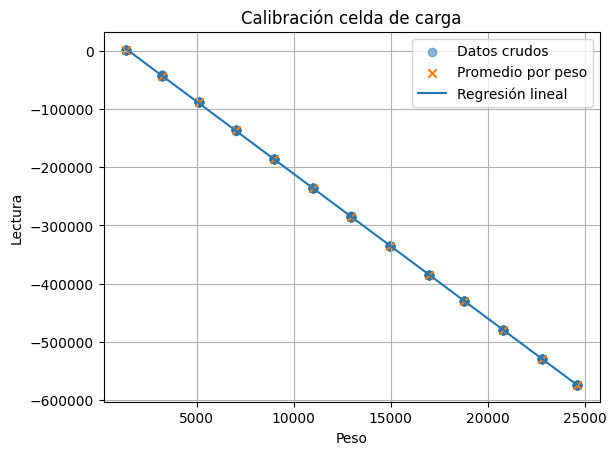

In [15]:
import numpy as np
import matplotlib.pyplot as plt

if df.empty:
    print("No hay datos")
else:
    # -------------------------
    # AGRUPACIÓN POR PESO
    # -------------------------
    df_group = df.groupby("Peso").agg(
        lectura_mean=("lectura", "mean"),
        lectura_std=("lectura", "std"),
        count=("lectura", "count")
    ).reset_index()

    print("=== Datos agrupados ===")
    display(df_group)

    # -------------------------
    # REGRESIÓN LINEAL
    # -------------------------
    x = df_group["Peso"].values
    y = df_group["lectura_mean"].values

    df_group["lectura_mean"] = pd.to_numeric(
    df_group["lectura_mean"],
    errors="coerce"
    )

    df_group["Peso"] = pd.to_numeric(
        df_group["Peso"],
        errors="coerce"
    )

    df_group = df_group.dropna(subset=["Peso", "lectura_mean"])

    x = df_group["Peso"].to_numpy(dtype=float)
    y = df_group["lectura_mean"].to_numpy(dtype=float)

    coef = np.polyfit(x, y, 1)
    pendiente, intercepto = coef

    print(f"\nRegresión: lectura = {pendiente:.6f} * Peso + {intercepto:.6f}")

    # -------------------------
    # VARIANZA GLOBAL
    # -------------------------
    std_total = df["lectura"].std()
    print(f"Std total: {std_total:.6f}")

    # -------------------------
    # RECTA PARA GRAFICAR
    # -------------------------
    x_fit = np.linspace(min(x), max(x), 100)
    y_fit = pendiente * x_fit + intercepto

    # -------------------------
    # GRÁFICA
    # -------------------------
    plt.figure()

    # Datos crudos
    plt.scatter(df["Peso"], df["lectura"], label="Datos crudos", alpha=0.5)

    # Promedios por peso
    plt.scatter(x, y, marker='x', label="Promedio por peso")

    # Recta de regresión
    plt.plot(x_fit, y_fit, label="Regresión lineal")

    plt.xlabel("Peso")
    plt.ylabel("Lectura")
    plt.title("Calibración celda de carga")
    plt.legend()
    plt.grid()

    plt.show()
    #-24570

In [45]:
!which python

/home/elreyrt/Documents/Calibracion_pai/venv/bin/python
